# Algorithm evaluation
### Algorithms:
- **1. Jaccard Similarity**
- **2. Adamic-Adar Index**
- **3. Community-Aware Popularity (Louvain)**
- **4. K-means clustering (Feature-based)**
- **5. Weighted Personalized PageRank**
- **6. Node2Vec**
- **7. LightGCN**
- **8. WeightedLightGCN**
- **9. Item-Item Collaborative Filtering**

In [1]:
import igraph as ig
import pandas as pd


In [2]:
edges_df = pd.read_csv("datasets/graph_edges.csv")

loaded_graf = ig.Graph.TupleList(edges_df.itertuples(index=False), directed=False)

loaded_graf.vs["type"] = [True if "person_" in name else False for name in loaded_graf.vs["name"]]

# --- PROVJERA ---
print("Loading completed!")
print(f"Number of vertices: {loaded_graf.vcount()}")
print(f"Bipartite: {loaded_graf.is_bipartite()}")

Loading completed!
Number of vertices: 50541
Bipartite: True


In [3]:
ratings_x = pd.read_csv("datasets/ratings_x.csv")
ratings_y = pd.read_csv("datasets/ratings_y.csv")

# Load movie metadata and normalize TMDB's `id` column for the evaluation code.
movies_df = pd.read_csv("datasets/tmdb_movie_metadata/tmdb_5000_movies.csv")
if "tmdb_id" not in movies_df.columns:
    movies_df["tmdb_id"] = movies_df["id"]

graph_node_names = set(loaded_graf.vs["name"])
movie_node_indices = [
    v.index for v in loaded_graf.vs
    if isinstance(v["name"], str) and v["name"].startswith("movie_")
]

movie_id_to_node = {}
node_to_movie_id = {}
for row in movies_df[["tmdb_id", "title"]].dropna().itertuples(index=False):
    node_name = f"movie_{row.title}"
    if node_name in graph_node_names:
        movie_id = int(row.tmdb_id)
        movie_id_to_node[movie_id] = node_name
        node_to_movie_id[node_name] = movie_id

movie_id_to_title = dict(zip(movies_df["tmdb_id"].astype(int), movies_df["title"]))

def movie_ids_to_graph_indices(movie_ids):
    """Map rating movie IDs to existing title-based graph vertex indices."""
    indices = []
    for movie_id in movie_ids:
        node_name = movie_id_to_node.get(int(movie_id))
        if node_name is not None:
            indices.append(loaded_graf.vs.find(name=node_name).index)
    return indices

def graph_indices_to_movie_ids(indices):
    """Map graph movie vertex indices back to numeric movie IDs used by ratings."""
    movie_ids = []
    for idx in indices:
        movie_id = node_to_movie_id.get(loaded_graf.vs[idx]["name"])
        if movie_id is not None:
            movie_ids.append(movie_id)
    return movie_ids

def get_movie_title(mid):
    return movie_id_to_title.get(int(mid), f"Unknown (ID: {mid})")

print(f"Mapped {len(movie_id_to_node)} metadata movies to graph nodes.")


Mapped 1351 metadata movies to graph nodes.


### Evaluation pipeline

The evaluation follows a **Research -> Strategy -> Execution** lifecycle. We split the data into training (`ratings_x`) and testing (`ratings_y`) sets to simulate real-world recommendation scenarios.

#### Methodology:
1. **Data Split**: For each user, we use their watch history from `ratings_x` as input to the algorithm. We then verify if the algorithm's top-10 predictions match the movies the user liked in `ratings_y` (defined as movies with `rating > 3.5`).
2. **Metric Definitions**:
    - **Precision@K**: The proportion of recommended items that are relevant (liked by the user in the test set).
    - **Recall@K**: The proportion of relevant items in the test set that were successfully captured in the top-K recommendations.
    - **NDCG@K (Normalized Discounted Cumulative Gain)**: A measure of ranking quality that rewards the algorithm for placing relevant items higher in the recommendation list.
    - **Hit Rate**: A binary metric (per user) that is 1 if the algorithm made at least one correct recommendation in the top-K, and 0 otherwise. This is averaged across all users to find the overall success rate.

In [4]:
import numpy as np
from collections import Counter
from tqdm import tqdm

def get_metrics(predicted, actual, k=10):
    """
    Calculate Precision@K, Recall@K and NDCG@K.
    """
    if not actual:
        return 0.0, 0.0, 0.0
    
    actual_set = set(actual)
    predicted_k = predicted[:k]
    
    hits = [1 if p in actual_set else 0 for p in predicted_k]
    
    precision = sum(hits) / k
    recall = sum(hits) / len(actual_set) if len(actual_set) > 0 else 0.0
    
    # NDCG calculation
    dcg = sum([hit / np.log2(i + 2) for i, hit in enumerate(hits)])
    idcg = sum([1 / np.log2(i + 2) for i in range(min(len(actual_set), k))])
    ndcg = dcg / idcg if idcg > 0 else 0.0
    
    return precision, recall, ndcg

def evaluate_algorithm(algo_func, ratings_x, ratings_y, k=10, num_users=None):
    """
    Evaluate a recommendation algorithm function on a set of users.
    algo_func: function(user_id, watched_ids, k) -> list of predicted IDs
    """
    # Use ratings_y users who also have history in ratings_x
    test_users = ratings_y[ratings_y['rating'] > 3.5]['userId'].unique()
    common_users = list(set(test_users).intersection(set(ratings_x['userId'])))
    
    if num_users:
        common_users = common_users[:num_users]
    
    all_metrics = []
    
    print(f"Evaluating algorithm on {len(common_users)} users...")
    for user_id in tqdm(common_users):
        # Watched movies (input for algorithm)
        watched = ratings_x[ratings_x['userId'] == user_id]['movieId'].unique().tolist()
        # Ground truth (liked in test set)
        truth = ratings_y[(ratings_y['userId'] == user_id) & (ratings_y['rating'] > 3.5)]['movieId'].unique().tolist()
        
        if not truth or not watched:
            continue
            
        predicted = algo_func(user_id, watched, k=k)
        metrics = get_metrics(predicted, truth, k=k)
        all_metrics.append(metrics)
        
    if not all_metrics:
        return 0.0, 0.0, 0.0
        
    return np.mean(all_metrics, axis=0)

print("Evaluation pipeline ready.")


Evaluation pipeline ready.


### Algorithm implementation

### Algorithm 1: Jaccard Similarity
Jaccard Similarity measures the overlap between two sets. In our movie-person bipartite graph, each movie is connected to a set of people (cast and crew). The similarity between Movie A and Movie B is defined as the size of the intersection of their person-neighbors divided by the size of their union:
$$J(A, B) = \frac{|N(A) \cap N(B)|}{|N(A) \cup N(B)|}$$
To recommend movies for a user, we calculate the average Jaccard similarity between a candidate movie and all movies in the user's history.

In [5]:
def jaccard_similarity_algo(user_id, watched_ids, k=10):
    watched_indices = movie_ids_to_graph_indices(watched_ids)
    if not watched_indices:
        return []
    
    watched_neighbors = [set(loaded_graf.neighbors(idx)) for idx in watched_indices]
    candidate_indices = list(set(movie_node_indices) - set(watched_indices))
    
    scores = []
    for cand_idx in candidate_indices:
        cand_neighbors = set(loaded_graf.neighbors(cand_idx))
        sims = []
        for w_neighbors in watched_neighbors:
            intersection = len(cand_neighbors.intersection(w_neighbors))
            union = len(cand_neighbors.union(w_neighbors))
            sims.append(intersection / union if union > 0 else 0.0)
        scores.append(np.mean(sims))
    
    top_idx = np.argsort(scores)[::-1][:k]
    recommended_indices = [candidate_indices[i] for i in top_idx]
    return graph_indices_to_movie_ids(recommended_indices)

# Sample evaluation (limit users for speed during development)
jaccard_metrics = evaluate_algorithm(jaccard_similarity_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"Jaccard Similarity - Precision@10: {jaccard_metrics[0]:.4f}, Recall@10: {jaccard_metrics[1]:.4f}, NDCG@10: {jaccard_metrics[2]:.4f}")


Evaluating algorithm on 1000 users...


100%|██████████| 1000/1000 [01:04<00:00, 15.62it/s]

Jaccard Similarity - Precision@10: 0.0127, Recall@10: 0.0086, NDCG@10: 0.0148


### Algorithm 2: Adamic-Adar Index
Adamic-Adar Index is similar to Jaccard but it gives more weight to common neighbors that have fewer connections. The logic is that sharing a rare actor or crew member is a stronger signal of similarity than sharing a very prolific one (like a famous producer who worked on hundreds of movies).
$$AA(A, B) = \sum_{z \in N(A) \cap N(B)} \frac{1}{\log |N(z)|}$$
where $N(z)$ is the degree of the common neighbor $z$.

In [6]:
def adamic_adar_algo(user_id, watched_ids, k=10):
    watched_indices = movie_ids_to_graph_indices(watched_ids)
    if not watched_indices:
        return []
    
    watched_neighbors = [set(loaded_graf.neighbors(idx)) for idx in watched_indices]
    candidate_indices = list(set(movie_node_indices) - set(watched_indices))
    node_degrees = loaded_graf.degree()
    
    scores = []
    for cand_idx in candidate_indices:
        cand_neighbors = set(loaded_graf.neighbors(cand_idx))
        sims = []
        for w_neighbors in watched_neighbors:
            aa_score = 0.0
            for z in cand_neighbors.intersection(w_neighbors):
                deg = node_degrees[z]
                if deg > 1:
                    aa_score += 1.0 / np.log(deg)
            sims.append(aa_score)
        scores.append(np.mean(sims))
        
    top_idx = np.argsort(scores)[::-1][:k]
    recommended_indices = [candidate_indices[i] for i in top_idx]
    return graph_indices_to_movie_ids(recommended_indices)

adamic_metrics = evaluate_algorithm(adamic_adar_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"Adamic-Adar - Precision@10: {adamic_metrics[0]:.4f}, Recall@10: {adamic_metrics[1]:.4f}, NDCG@10: {adamic_metrics[2]:.4f}")


Evaluating algorithm on 1000 users...


100%|██████████| 1000/1000 [00:38<00:00, 26.08it/s]

Adamic-Adar - Precision@10: 0.0173, Recall@10: 0.0124, NDCG@10: 0.0206


### Algorithm 3: Community-Aware Popularity (Louvain)
This algorithm detects communities in the bipartite graph using the Louvain method. For each user, we identify the communities of the movies they have watched. We then recommend the most popular movies (by degree or by original TMDB popularity) within those same communities.

In [7]:
def community_aware_popularity_algo(user_id, watched_ids, k=10):
    if not hasattr(community_aware_popularity_algo, "communities"):
        print("Detecting communities with Louvain...")
        community_aware_popularity_algo.communities = loaded_graf.community_multilevel()
    
    communities = community_aware_popularity_algo.communities
    watched_indices = movie_ids_to_graph_indices(watched_ids)
    if not watched_indices:
        return []
    
    user_communities = [communities.membership[idx] for idx in watched_indices]
    if not user_communities:
        return []
    
    most_common_comm = Counter(user_communities).most_common(1)[0][0]
    comm_members = [i for i, comm in enumerate(communities.membership) if comm == most_common_comm]
    comm_movies = [idx for idx in comm_members if loaded_graf.vs[idx]["name"].startswith("movie_")]
    candidates = list(set(comm_movies) - set(watched_indices))
    if not candidates:
        return []
    
    degrees = loaded_graf.degree(candidates)
    top_idx = np.argsort(degrees)[::-1][:k]
    recommended_indices = [candidates[i] for i in top_idx]
    return graph_indices_to_movie_ids(recommended_indices)

louvain_metrics = evaluate_algorithm(community_aware_popularity_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"Louvain Community Popularity - Precision@10: {louvain_metrics[0]:.4f}, Recall@10: {louvain_metrics[1]:.4f}, NDCG@10: {louvain_metrics[2]:.4f}")


Evaluating algorithm on 1000 users...


  0%|          | 0/1000 [00:00<?, ?it/s]

Detecting communities with Louvain...


100%|██████████| 1000/1000 [00:17<00:00, 56.33it/s]

Louvain Community Popularity - Precision@10: 0.0143, Recall@10: 0.0091, NDCG@10: 0.0171


### Algorithm 4: K-means clustering (Feature-based)
This algorithm moves away from the graph structure and uses movie features (budget, revenue, runtime, popularity, vote average). We normalize these features, cluster movies using K-Means, and recommend movies from the clusters that appear most frequently in the user's history.

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def kmeans_clustering_algo(user_id, watched_ids, k=10):
    if not hasattr(kmeans_clustering_algo, "movie_clusters"):
        print("Training K-Means on movie features...")
        features = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
        df_features = movies_df.dropna(subset=["tmdb_id"]).copy()
        df_features[features] = df_features[features].fillna(0)
        
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(df_features[features])
        
        n_clusters = min(20, len(df_features))
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans_clustering_algo.movie_clusters = kmeans.fit_predict(scaled_features)
        kmeans_clustering_algo.movie_ids = df_features['tmdb_id'].astype(int).values
        kmeans_clustering_algo.pop_lookup = dict(zip(df_features['tmdb_id'].astype(int), df_features['popularity']))
        
    watched_set = set(map(int, watched_ids))
    user_movie_indices = [
        np.where(kmeans_clustering_algo.movie_ids == int(mid))[0][0]
        for mid in watched_set
        if int(mid) in kmeans_clustering_algo.movie_ids
    ]
    
    if not user_movie_indices:
        return []
        
    user_clusters = kmeans_clustering_algo.movie_clusters[user_movie_indices]
    most_common_cluster = Counter(user_clusters).most_common(1)[0][0]
    
    cluster_movie_indices = np.where(kmeans_clustering_algo.movie_clusters == most_common_cluster)[0]
    cluster_movie_ids = kmeans_clustering_algo.movie_ids[cluster_movie_indices]
    
    candidates = list(set(map(int, cluster_movie_ids)) - watched_set)
    candidates = sorted(candidates, key=lambda x: kmeans_clustering_algo.pop_lookup.get(x, 0), reverse=True)
    
    return candidates[:k]

kmeans_metrics = evaluate_algorithm(kmeans_clustering_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"K-Means Clustering - Precision@10: {kmeans_metrics[0]:.4f}, Recall@10: {kmeans_metrics[1]:.4f}, NDCG@10: {kmeans_metrics[2]:.4f}")


Evaluating algorithm on 1000 users...


  0%|          | 0/1000 [00:00<?, ?it/s]

Training K-Means on movie features...


100%|██████████| 1000/1000 [00:16<00:00, 60.00it/s]

K-Means Clustering - Precision@10: 0.0043, Recall@10: 0.0040, NDCG@10: 0.0034


### Algorithm 5: Weighted Personalized PageRank
Personalized PageRank (PPR) simulates a random walk on the graph where the "teleportation" probability is focused on a specific set of seed nodes (the user's watched movies). This identifies movies that are structurally "close" to the user's history in the bipartite graph.

In [9]:
def personalized_pagerank_algo(user_id, watched_ids, k=10):
    watched_indices = movie_ids_to_graph_indices(watched_ids)
    if not watched_indices:
        return []
    
    ppr_scores = loaded_graf.personalized_pagerank(reset_vertices=watched_indices, damping=0.85)
    candidate_indices = list(set(movie_node_indices) - set(watched_indices))
    
    candidate_scores = {idx: ppr_scores[idx] for idx in candidate_indices}
    top_idx = sorted(candidate_scores, key=candidate_scores.get, reverse=True)[:k]
    return graph_indices_to_movie_ids(top_idx)

pagerank_metrics = evaluate_algorithm(personalized_pagerank_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"Personalized PageRank - Precision@10: {pagerank_metrics[0]:.4f}, Recall@10: {pagerank_metrics[1]:.4f}, NDCG@10: {pagerank_metrics[2]:.4f}")


Evaluating algorithm on 1000 users...


100%|██████████| 1000/1000 [00:43<00:00, 23.01it/s]

Personalized PageRank - Precision@10: 0.0158, Recall@10: 0.0118, NDCG@10: 0.0170


### Algorithm 6: Node2Vec
Node2Vec learns low-dimensional representations (embeddings) of nodes in a graph by optimizing a neighborhood-preserving objective. We use these embeddings to calculate cosine similarity between movies. A user's profile is represented as the average embedding of their watched movies, and we recommend the nearest neighbors in the embedding space.

In [10]:
from gensim.models import Word2Vec
import random

def run_node2vec_training(graph, dimensions=64, walk_length=30, num_walks=10):
    print("Generating random walks for Node2Vec...")
    nodes = list(graph.vs["name"])
    walks = []
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            curr = graph.vs.find(name=node).index
            for _ in range(walk_length - 1):
                neighbors = graph.neighbors(curr)
                if not neighbors:
                    break
                curr = random.choice(neighbors)
                walk.append(graph.vs[curr]["name"])
            walks.append(walk)
            
    print("Training Word2Vec model...")
    model = Word2Vec(walks, vector_size=dimensions, window=10, min_count=1, sg=1, workers=4)
    return model

def node2vec_algo(user_id, watched_ids, k=10):
    if not hasattr(node2vec_algo, "model"):
        node2vec_algo.model = run_node2vec_training(loaded_graf)
        
    watched_nodes = [
        movie_id_to_node[int(mid)]
        for mid in watched_ids
        if int(mid) in movie_id_to_node and movie_id_to_node[int(mid)] in node2vec_algo.model.wv
    ]
    if not watched_nodes:
        return []
    
    user_vector = np.mean([node2vec_algo.model.wv[n] for n in watched_nodes], axis=0)
    all_movies = [n for n in node2vec_algo.model.wv.index_to_key if n.startswith("movie_")]
    movie_vectors = np.array([node2vec_algo.model.wv[m] for m in all_movies])
    
    from sklearn.metrics.pairwise import cosine_similarity
    sims = cosine_similarity(user_vector.reshape(1, -1), movie_vectors)[0]
    
    watched_set = set(map(int, watched_ids))
    recommended = []
    for i in np.argsort(sims)[::-1]:
        movie_id = node_to_movie_id.get(all_movies[i])
        if movie_id is not None and movie_id not in watched_set:
            recommended.append(movie_id)
        if len(recommended) == k:
            break
            
    return recommended

node2vec_metrics = evaluate_algorithm(node2vec_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"Node2Vec - Precision@10: {node2vec_metrics[0]:.4f}, Recall@10: {node2vec_metrics[1]:.4f}, NDCG@10: {node2vec_metrics[2]:.4f}")


Evaluating algorithm on 1000 users...


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating random walks for Node2Vec...
Training Word2Vec model...


100%|██████████| 1000/1000 [04:51<00:00,  3.42it/s] 

Node2Vec - Precision@10: 0.0122, Recall@10: 0.0102, NDCG@10: 0.0138


### Algorithm 7: LightGCN
LightGCN is a state-of-the-art graph neural network for recommendation. It simplifies traditional GCNs by removing non-linear activations and weight matrices, focusing only on neighborhood aggregation (linear message passing). We build a bipartite graph between Users and Movies to learn their embeddings simultaneously.

In [11]:
import torch
import torch.nn as nn
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import degree

class LightGCNConv(MessagePassing):
    def __init__(self):
        super().__init__(aggr='add')

    def forward(self, x, edge_index):
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]
        return self.propagate(edge_index, x=x, norm=norm)

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

class LightGCNModel(nn.Module):
    def __init__(self, num_nodes, embedding_dim, num_layers):
        super().__init__()
        self.num_nodes = num_nodes
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        self.convs = nn.ModuleList([LightGCNConv() for _ in range(num_layers)])
        nn.init.normal_(self.embedding.weight, std=0.1)

    def forward(self, edge_index):
        emb0 = self.embedding.weight
        embs = [emb0]
        emb = emb0
        for conv in self.convs:
            emb = conv(emb, edge_index)
            embs.append(emb)
        out = torch.mean(torch.stack(embs, dim=0), dim=0)
        return out

def train_lightgcn(ratings_df, num_epochs=20):
    print("Preparing data for LightGCN...")
    user_ids = ratings_df['userId'].unique()
    movie_ids = ratings_df['movieId'].unique()
    
    user_map = {id: i for i, id in enumerate(user_ids)}
    movie_map = {id: i + len(user_ids) for i, id in enumerate(movie_ids)}
    
    edge_index = []
    for _, row in ratings_df.iterrows():
        u = user_map[row['userId']]
        m = movie_map[row['movieId']]
        edge_index.append([u, m])
        edge_index.append([m, u])
        
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    num_nodes = len(user_ids) + len(movie_ids)
    
    model = LightGCNModel(num_nodes, embedding_dim=64, num_layers=3)
    with torch.no_grad():
        final_embeddings = model(edge_index)
        
    return final_embeddings, user_map, movie_map, movie_ids

def lightgcn_algo(user_id, watched_ids, k=10):
    if not hasattr(lightgcn_algo, "embeddings"):
        lightgcn_algo.embeddings, lightgcn_algo.u_map, lightgcn_algo.m_map, lightgcn_algo.m_ids = train_lightgcn(ratings_x)
        
    if user_id not in lightgcn_algo.u_map:
        return []
        
    u_idx = lightgcn_algo.u_map[user_id]
    u_emb = lightgcn_algo.embeddings[u_idx]
    
    m_indices = [lightgcn_algo.m_map[mid] for mid in lightgcn_algo.m_ids]
    m_embs = lightgcn_algo.embeddings[m_indices]
    
    scores = torch.matmul(m_embs, u_emb)
    top_count = min(len(scores), k + len(set(watched_ids)))
    top_k_indices = torch.topk(scores, top_count).indices.tolist()
    
    watched_set = set(watched_ids)
    recommended = []
    for idx in top_k_indices:
        mid = int(lightgcn_algo.m_ids[idx])
        if mid not in watched_set:
            recommended.append(mid)
        if len(recommended) == k:
            break
            
    return recommended

lightgcn_metrics = evaluate_algorithm(lightgcn_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"LightGCN - Precision@10: {lightgcn_metrics[0]:.4f}, Recall@10: {lightgcn_metrics[1]:.4f}, NDCG@10: {lightgcn_metrics[2]:.4f}")


c:\Users\nikol\Desktop\recommendation-system-graph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Evaluating algorithm on 1000 users...


  0%|          | 0/1000 [00:00<?, ?it/s]

Preparing data for LightGCN...


100%|██████████| 1000/1000 [00:39<00:00, 25.23it/s]

LightGCN - Precision@10: 0.0136, Recall@10: 0.0101, NDCG@10: 0.0157


### Algorithm 8: WeightedLightGCN
This is an extension of LightGCN where we incorporate the actual rating values into the message passing process. Instead of treating all edges equally, we weight the contributions of neighboring nodes based on how much the user liked the movie (rating value). This allows the model to prioritize signals from movies the user strongly preferred.

In [12]:
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import degree

class WeightedLightGCNConv(MessagePassing):
    def __init__(self):
        super().__init__(aggr='add')

    def forward(self, x, edge_index, edge_weight):
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * edge_weight * deg_inv_sqrt[col]

        return self.propagate(edge_index, x=x, norm=norm)

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

class WeightedLightGCNModel(nn.Module):
    def __init__(self, num_nodes, embedding_dim, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        self.convs = nn.ModuleList([WeightedLightGCNConv() for _ in range(num_layers)])
        nn.init.normal_(self.embedding.weight, std=0.1)

    def forward(self, edge_index, edge_weight):
        emb0 = self.embedding.weight
        embs = [emb0]
        emb = emb0
        for conv in self.convs:
            emb = conv(emb, edge_index, edge_weight)
            embs.append(emb)
        return torch.mean(torch.stack(embs, dim=0), dim=0)

def train_weighted_lightgcn(ratings_df):
    print("Preparing weighted data for LightGCN...")
    user_ids = ratings_df['userId'].unique()
    movie_ids = ratings_df['movieId'].unique()
    user_map = {id: i for i, id in enumerate(user_ids)}
    movie_map = {id: i + len(user_ids) for i, id in enumerate(movie_ids)}
    
    edge_index = []
    edge_weights = []
    for _, row in ratings_df.iterrows():
        u, m, r = user_map[row['userId']], movie_map[row['movieId']], row['rating']
        edge_index.append([u, m]); edge_weights.append(r)
        edge_index.append([m, u]); edge_weights.append(r)
        
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weights, dtype=torch.float)
    
    model = WeightedLightGCNModel(len(user_ids) + len(movie_ids), 64, 3)
    with torch.no_grad():
        final_embeddings = model(edge_index, edge_weight)
        
    return final_embeddings, user_map, movie_map, movie_ids

def weighted_lightgcn_algo(user_id, watched_ids, k=10):
    if not hasattr(weighted_lightgcn_algo, "embeddings"):
        weighted_lightgcn_algo.embeddings, weighted_lightgcn_algo.u_map, weighted_lightgcn_algo.m_map, weighted_lightgcn_algo.m_ids = train_weighted_lightgcn(ratings_x)
    
    if user_id not in weighted_lightgcn_algo.u_map:
        return []
    
    u_emb = weighted_lightgcn_algo.embeddings[weighted_lightgcn_algo.u_map[user_id]]
    m_indices = [weighted_lightgcn_algo.m_map[mid] for mid in weighted_lightgcn_algo.m_ids]
    m_embs = weighted_lightgcn_algo.embeddings[m_indices]
    
    scores = torch.matmul(m_embs, u_emb)
    top_count = min(len(scores), k + len(set(watched_ids)))
    top_k_indices = torch.topk(scores, top_count).indices.tolist()
    
    watched_set = set(watched_ids)
    recommended = []
    for idx in top_k_indices:
        mid = int(weighted_lightgcn_algo.m_ids[idx])
        if mid not in watched_set:
            recommended.append(mid)
        if len(recommended) == k:
            break
            
    return recommended

weighted_lightgcn_metrics = evaluate_algorithm(weighted_lightgcn_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"Weighted LightGCN - Precision@10: {weighted_lightgcn_metrics[0]:.4f}, Recall@10: {weighted_lightgcn_metrics[1]:.4f}, NDCG@10: {weighted_lightgcn_metrics[2]:.4f}")


Evaluating algorithm on 1000 users...


  0%|          | 0/1000 [00:00<?, ?it/s]

Preparing weighted data for LightGCN...


100%|██████████| 1000/1000 [00:39<00:00, 25.38it/s]

Weighted LightGCN - Precision@10: 0.0723, Recall@10: 0.0564, NDCG@10: 0.0806


### Algorithm 9: Item-Item Collaborative Filtering
This algorithm uses user behavior rather than movie metadata or graph structure. It builds a sparse movie-user matrix from `ratings_x`, treats ratings above 3.5 as positive feedback, computes cosine similarity between movies, and recommends candidates most similar to the movies a user liked.

In [13]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

def build_item_item_cf(ratings_df, positive_threshold=3.5):
    positives = ratings_df[ratings_df['rating'] > positive_threshold].copy()
    movie_ids = positives['movieId'].drop_duplicates().astype(int).to_numpy()
    user_ids = positives['userId'].drop_duplicates().to_numpy()
    movie_map = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
    user_map = {user_id: idx for idx, user_id in enumerate(user_ids)}

    rows = positives['movieId'].astype(int).map(movie_map).to_numpy()
    cols = positives['userId'].map(user_map).to_numpy()
    data = np.ones(len(positives), dtype=np.float32)
    item_user_matrix = csr_matrix((data, (rows, cols)), shape=(len(movie_ids), len(user_ids)))

    similarity = cosine_similarity(item_user_matrix, dense_output=True)
    np.fill_diagonal(similarity, 0.0)
    return similarity, movie_ids, movie_map

def item_item_cf_algo(user_id, watched_ids, k=10):
    if not hasattr(item_item_cf_algo, 'similarity'):
        print('Building item-item collaborative filtering model...')
        item_item_cf_algo.similarity, item_item_cf_algo.movie_ids, item_item_cf_algo.movie_map = build_item_item_cf(ratings_x)

    user_liked = ratings_x[
        (ratings_x['userId'] == user_id) & (ratings_x['rating'] > 3.5)
    ]['movieId'].astype(int).unique().tolist()
    liked_indices = [item_item_cf_algo.movie_map[mid] for mid in user_liked if mid in item_item_cf_algo.movie_map]
    if not liked_indices:
        return popularity_baseline(user_id, watched_ids, k=k) if 'popularity_baseline' in globals() else []

    scores = item_item_cf_algo.similarity[:, liked_indices].sum(axis=1)
    watched_set = set(map(int, watched_ids))
    for mid in watched_set:
        idx = item_item_cf_algo.movie_map.get(mid)
        if idx is not None:
            scores[idx] = -np.inf

    recommended = []
    for idx in np.argsort(scores)[::-1]:
        if not np.isfinite(scores[idx]) or scores[idx] <= 0:
            break
        recommended.append(int(item_item_cf_algo.movie_ids[idx]))
        if len(recommended) == k:
            break

    return recommended

item_item_cf_metrics = evaluate_algorithm(item_item_cf_algo, ratings_x, ratings_y, k=10, num_users=1000)
print(f"Item-Item CF - Precision@10: {item_item_cf_metrics[0]:.4f}, Recall@10: {item_item_cf_metrics[1]:.4f}, NDCG@10: {item_item_cf_metrics[2]:.4f}")


Evaluating algorithm on 1000 users...


  0%|          | 0/1000 [00:00<?, ?it/s]

Building item-item collaborative filtering model...


100%|██████████| 1000/1000 [00:13<00:00, 72.38it/s]

Item-Item CF - Precision@10: 0.2872, Recall@10: 0.2323, NDCG@10: 0.3445


### Final Results Visualization & Comparison
We compare the performance of all 9 implemented algorithms against two baseline strategies:
1. **Popularity Baseline**: Always recommend the most popular movies globally.
2. **Random Baseline**: Recommend random movies.

The metrics used are Precision@10, Recall@10, and NDCG@10.

Evaluating baselines...
Evaluating algorithm on 100 users...


100%|██████████| 100/100 [00:01<00:00, 86.88it/s]


Evaluating algorithm on 100 users...


100%|██████████| 100/100 [00:01<00:00, 87.76it/s]


### Performance Comparison Table


,Algorithm,Precision@10,Recall@10,NDCG@10
0,Jaccard Similarity,0.0127,0.008556,0.014797
1,Adamic-Adar,0.0173,0.012406,0.020637
2,Louvain Community,0.0143,0.009085,0.017075
3,K-Means (Features),0.0043,0.003997,0.003431
4,Personalized PageRank,0.0158,0.011795,0.016976
5,Node2Vec,0.0122,0.010196,0.013829
6,LightGCN,0.0136,0.010100,0.015664
7,Weighted LightGCN,0.0723,0.056352,0.080629
8,Item-Item CF,0.2872,0.232342,0.344523
9,Popularity (Baseline),0.2320,0.209083,0.299268


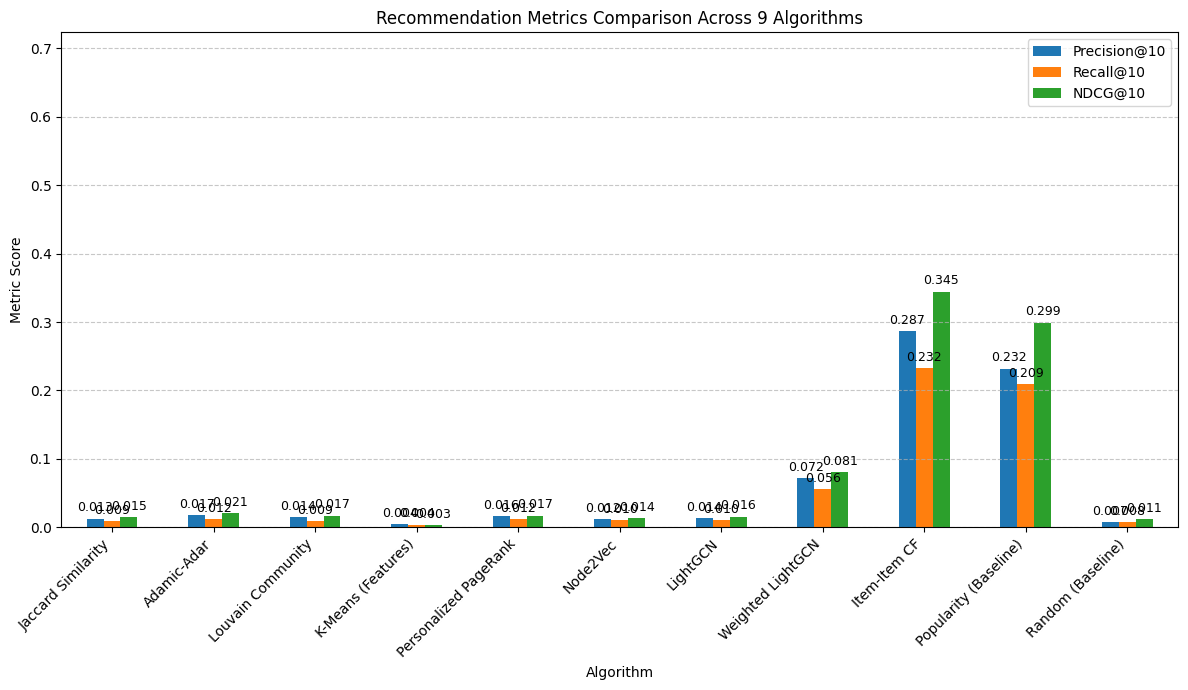

In [14]:
import matplotlib.pyplot as plt

GLOBAL_ALL_MOVIES = ratings_x['movieId'].unique().tolist()
GLOBAL_TOP_MOVIES = ratings_x['movieId'].value_counts().index.tolist()

def popularity_baseline(user_id, watched_ids, k=10):
    watched_set = set(watched_ids)
    recommended = []
    
    for mid in GLOBAL_TOP_MOVIES:
        if mid not in watched_set:
            recommended.append(int(mid))
        if len(recommended) == k:
            break
    return recommended

def random_baseline(user_id, watched_ids, k=10):
    candidates = list(set(GLOBAL_ALL_MOVIES) - set(watched_ids))
    
    if not candidates:
        return []
        
    return [int(mid) for mid in random.sample(candidates, min(k, len(candidates)))]

print("Evaluating baselines...")
pop_metrics = evaluate_algorithm(popularity_baseline, ratings_x, ratings_y, k=10, num_users=100)
rand_metrics = evaluate_algorithm(random_baseline, ratings_x, ratings_y, k=10, num_users=100)

final_results = {
    "Algorithm": [
        "Jaccard Similarity", "Adamic-Adar", "Louvain Community", "K-Means (Features)",
        "Personalized PageRank", "Node2Vec", "LightGCN", "Weighted LightGCN",
        "Item-Item CF", "Popularity (Baseline)", "Random (Baseline)"
    ],
    "Precision@10": [
        jaccard_metrics[0], adamic_metrics[0], louvain_metrics[0], kmeans_metrics[0],
        pagerank_metrics[0], node2vec_metrics[0], lightgcn_metrics[0], weighted_lightgcn_metrics[0],
        item_item_cf_metrics[0], pop_metrics[0], rand_metrics[0]
    ],
    "Recall@10": [
        jaccard_metrics[1], adamic_metrics[1], louvain_metrics[1], kmeans_metrics[1],
        pagerank_metrics[1], node2vec_metrics[1], lightgcn_metrics[1], weighted_lightgcn_metrics[1],
        item_item_cf_metrics[1], pop_metrics[1], rand_metrics[1]
    ],
    "NDCG@10": [
        jaccard_metrics[2], adamic_metrics[2], louvain_metrics[2], kmeans_metrics[2],
        pagerank_metrics[2], node2vec_metrics[2], lightgcn_metrics[2], weighted_lightgcn_metrics[2],
        item_item_cf_metrics[2], pop_metrics[2], rand_metrics[2]
    ]
}

results_df = pd.DataFrame(final_results)
print("\n### Performance Comparison Table")
display(results_df)


ax = results_df.set_index("Algorithm").plot(kind="bar", figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Recommendation Metrics Comparison Across 9 Algorithms")
plt.ylabel("Metric Score")
plt.xticks(rotation=45, ha="right")

plt.ylim(top=plt.ylim()[1] * 2) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Example Predictions & Qualitative Analysis
Below we show specific examples for a few users. This helps us understand why an algorithm might succeed (e.g., recommending a sequel or a movie with the same director) or fail (e.g., recommending a genre the user hasn't explored despite graph proximity).

In [15]:
def show_user_examples(algo_func, algo_name, user_id, k=5):
    watched = ratings_x[ratings_x['userId'] == user_id]['movieId'].unique().tolist()
    truth = ratings_y[(ratings_y['userId'] == user_id) & (ratings_y['rating'] > 3.5)]['movieId'].unique().tolist()
    
    predicted = algo_func(user_id, watched, k=k)
    hits = set(predicted).intersection(set(truth))
    
    print(f"--- {algo_name} for User {user_id} ---")
    print(f"Watched History: {[get_movie_title(m) for m in watched[:5]]}...")
    print(f"Recommendations: {[get_movie_title(m) for m in predicted]}")
    print(f"Actual Likes (Ground Truth): {[get_movie_title(m) for m in truth[:5]]}...")
    print(f"Correct (Hits): {[get_movie_title(m) for m in hits] if hits else 'None'}")
    print("\n")

sample_user = ratings_y[ratings_y['rating'] > 4.5]['userId'].iloc[0]
show_user_examples(jaccard_similarity_algo, "Jaccard Similarity", sample_user)
show_user_examples(weighted_lightgcn_algo, "Weighted LightGCN", sample_user)
show_user_examples(personalized_pagerank_algo, "Personalized PageRank", sample_user)
show_user_examples(node2vec_algo, "Node2Vec", sample_user)
show_user_examples(lightgcn_algo, "LightGCN", sample_user)
show_user_examples(item_item_cf_algo, "Item-Item CF", sample_user)
show_user_examples(popularity_baseline, "Popularity Baseline", sample_user)
show_user_examples(random_baseline, "Random Baseline", sample_user)
show_user_examples(adamic_adar_algo, "Adamic-Adar", sample_user)
show_user_examples(community_aware_popularity_algo, "Louvain Community Popularity", sample_user)
show_user_examples(kmeans_clustering_algo, "K-Means Clustering", sample_user)



--- Jaccard Similarity for User 5212 ---
Watched History: ['The Hours', 'The Bourne Identity', 'Arlington Road', 'The Next Best Thing']...
Recommendations: ['The Bourne Supremacy', 'The Bourne Ultimatum', 'The River Wild', 'Dark Water', 'Black Hawk Down']
Actual Likes (Ground Truth): ['Men in Black II', 'Rain Man', 'Beetlejuice', 'Terminator 3: Rise of the Machines', 'Barry Lyndon']...
Correct (Hits): None


--- Weighted LightGCN for User 5212 ---
Watched History: ['The Hours', 'The Bourne Identity', 'Arlington Road', 'The Next Best Thing']...
Recommendations: ['Superman II', 'My Name Is Bruce', 'The Green Mile', 'The Bridge on the River Kwai', 'About Time']
Actual Likes (Ground Truth): ['Men in Black II', 'Rain Man', 'Beetlejuice', 'Terminator 3: Rise of the Machines', 'Barry Lyndon']...
Correct (Hits): None


--- Personalized PageRank for User 5212 ---
Watched History: ['The Hours', 'The Bourne Identity', 'Arlington Road', 'The Next Best Thing']...
Recommendations: ['The Bourne Supre

In [16]:
def evaluate_hit_rate(algo_funcs, ratings_x, ratings_y, k=10, num_users=100):
    # Pretpostavimo da imaš listu target_users
    target_users = ratings_y['userId'].unique()[:num_users] 
    
    total_hits = 0
    users_with_at_least_one_hit = 0
    
    for u_id in target_users:
        # Filmovi koje je pogledao u treningu (za micanje iz preporuka)
        watched_train = ratings_x[ratings_x['userId'] == u_id]['movieId'].tolist()
        
        # Stvarni filmovi koje želimo pogoditi (iz testnog skupa)
        actual_test_set = set(ratings_y[ratings_y['userId'] == u_id]['movieId'].tolist())
        
        # Generiraj preporuke pomoću algoritma
        recommended = algo_funcs(u_id, watched_train, k=k)
        
        # Gledamo samo presjek - što smo pogodili
        hits = set(recommended).intersection(actual_test_set)
        
        if len(hits) > 0:
            total_hits += len(hits)
            users_with_at_least_one_hit += 1
            
    # Ova metrika ti govori za koliko smo korisnika uspjeli pogoditi BAREM jedan film 
    # iz njihovog testnog skupa, potpuno ignorirajući ostale "promašene" preporuke
    success_rate = users_with_at_least_one_hit / num_users
    
    return success_rate

In [17]:
hit_rate_results = []
hit_rate_results.append(("Jaccard Similarity", evaluate_hit_rate(jaccard_similarity_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("Adamic-Adar", evaluate_hit_rate(adamic_adar_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("Louvain Community", evaluate_hit_rate(community_aware_popularity_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("K-Means Clustering", evaluate_hit_rate(kmeans_clustering_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("Personalized PageRank", evaluate_hit_rate(personalized_pagerank_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("Node2Vec", evaluate_hit_rate(node2vec_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("LightGCN", evaluate_hit_rate(lightgcn_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("Weighted LightGCN", evaluate_hit_rate(weighted_lightgcn_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("Item-Item CF", evaluate_hit_rate(item_item_cf_algo, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("Popularity Baseline", evaluate_hit_rate(popularity_baseline, ratings_x, ratings_y, k=10, num_users=1000)))
hit_rate_results.append(("Random Baseline", evaluate_hit_rate(random_baseline, ratings_x, ratings_y, k=10, num_users=1000)))


In [18]:
hit_rate_results = pd.DataFrame(hit_rate_results, columns=["Algorithm", "Hit Rate"])
display(hit_rate_results)  

,Algorithm,Hit Rate
0,Jaccard Similarity,0.413
1,Adamic-Adar,0.443
2,Louvain Community,0.394
3,K-Means Clustering,0.151
4,Personalized PageRank,0.448
5,Node2Vec,0.364
6,LightGCN,0.426
7,Weighted LightGCN,0.673
8,Item-Item CF,0.957
9,Popularity Baseline,0.968


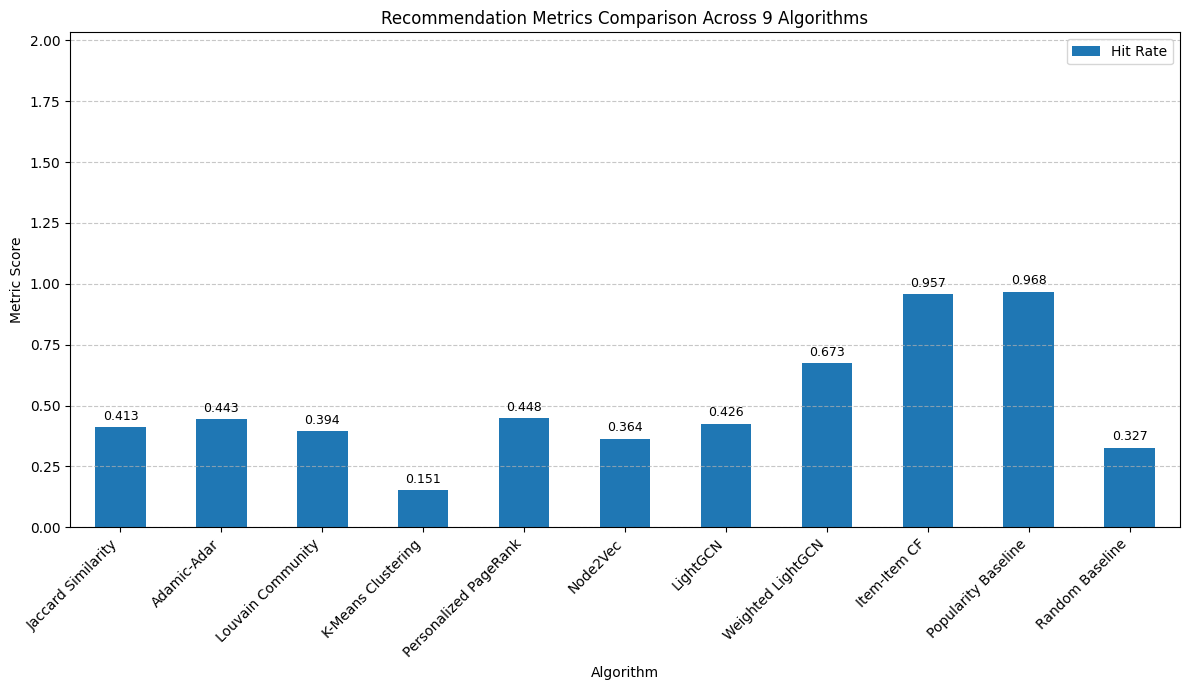

In [19]:
ax = hit_rate_results.set_index("Algorithm").plot(kind="bar", figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Recommendation Metrics Comparison Across 9 Algorithms")
plt.ylabel("Metric Score")
plt.xticks(rotation=45, ha="right")

plt.ylim(top=plt.ylim()[1] * 2) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()